In [1]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('combined_metrics_test_v5.csv')

print(df.shape)
df.dropna(subset=['value'], inplace=True)
print(df.shape)
# Print unique values for each column
for column in df.columns[:-1]:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


(758, 13)
(758, 13)

Unique values in algo:
['MACE' 'UCE' 'ESD' 'SDD']

Unique values in change:
['baseline' 'full_train' 'noxattn_train']

Unique values in task:
['copyright' 'object' 'celebrity' 'unsafe_content']

Unique values in config:
['erase_copyright_1' 'erase_ship' 'erase_cele_1' 'erase_cele_10'
 'erase_object_5' 'erase_cele_5' 'erase_cele_100' 'erase_object_3'
 'erase_unsafe_content']

Unique values in finetune_algo:
['none' 'lora' 'full' 'cfr_full']

Unique values in finetune_task:
['none' 'copyright' 'object' 'celebrity' 'art' 'unsafe_content']

Unique values in finetune_prompts:
['none' 'copyright_random_concepts_seed0' 'object_random_concepts_seed0'
 'celebrity_random_concepts_seed0' 'celebrity_10_clip_0'
 'celebrity_10_clip_1' 'art_random_concepts_seed0' 'celebrity_10_clip_2'
 'benign_concepts' 'coco_250']

Unique values in prompts_csv:
['copyright_1_concepts' 'object_ship_concepts' 'celebrity_1_concepts'
 'celebrity_10_concepts' 'object_5_concepts' 'celebrity_5_concepts

In [8]:
print(df['task'].unique())
fig1_df = df[df['config'].isin(['erase_copyright_1', 'erase_cele_100', 'erase_unsafe_content', 'erase_object_3'])]
print(fig1_df['task'].unique())

fig1_df = fig1_df[fig1_df['model_type'] == 'SD21']
print(fig1_df['task'].unique())

fig1_df = fig1_df[fig1_df['type'] != 'others']
fig1_df = fig1_df[fig1_df['type'] != 'mscoco-10k']
fig1_df = fig1_df[fig1_df['type'] != 'synonyms']
print(fig1_df['task'].unique())
fig1_df = fig1_df[(fig1_df['task'] == fig1_df['finetune_task']) | (fig1_df['finetune_task'] == 'none')]
print(fig1_df['task'].unique())
fig1_df
finetune_prompts_list = ['copyright_random_concepts_seed0', 'object_random_concepts_seed0', 'benign_concepts', 'none', 'celebrity_random_concepts_seed0']
fig1_df = fig1_df[fig1_df['finetune_prompts'].isin(finetune_prompts_list)]

['copyright' 'object' 'celebrity' 'unsafe_content']
['copyright' 'celebrity' 'object' 'unsafe_content']
['unsafe_content' 'copyright' 'celebrity']
['unsafe_content' 'copyright' 'celebrity']
['unsafe_content' 'copyright' 'celebrity']


In [9]:

grouped_df = fig1_df.groupby(['task', 'algo', 'finetune_algo']).agg({
    'value': list,
    'finetune_task': list,
    'type': list,
    'prompts_csv': list,
    'seed': list
}).reset_index()

# grouped_df = fig1_df.groupby(['task', 'algo', 'finetune_algo']).agg({
#     col: list for col in fig1_df.columns 
#     if col not in ['task', 'algo', 'finetune_algo']
# }).reset_index()

# Sort the grouped dataframe
grouped_df = grouped_df.sort_values(['task', 'algo', 'finetune_algo'])

# Filter to cases with more than 3 seeds
# First group and filter, then get unique values for the filtered groups
debug_df = (fig1_df.groupby(['task', 'algo', 'finetune_algo'])
              .agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              })
              .reset_index()
              .pipe(lambda df: df[df['seed'].apply(len) > 3])  # Filter to >3 seeds
              .assign(
                  value=lambda x: x['value'].apply(set),
                  finetune_task=lambda x: x['finetune_task'].apply(set),
                  type=lambda x: x['type'].apply(set),
                  prompts_csv=lambda x: x['prompts_csv'].apply(set),
                  seed=lambda x: x['seed'].apply(set)
              ))
fig1_df.groupby(['task', 'algo', 'finetune_algo']).agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              }).reset_index().pipe(lambda df: df[df['seed'].apply(len) > 3])


,task,algo,finetune_algo,value,finetune_task,type,prompts_csv,seed


In [10]:
import numpy as np

def format_value_range(values):
    values = [float(v) if isinstance(v, str) else v for v in values]  # Convert strings to floats
    if len(values) != 3:
        raise ValueError(f"Expected exactly 3 values for computing range, got {len(values)} values")
    min_val = min(values)
    max_val = max(values)
    median = np.median(values)
    diff = max(abs(max_val - median), abs(min_val - median))
    return f"{median:.3f} $\pm$ {diff:.3f}"

# Convert string values to floats before creating pivot table
fig1_df['value'] = fig1_df['value'].apply(lambda x: float(x) if isinstance(x, str) else x)

# Create a new column that combines 'lora' and 'full' into 'after_finetuning'
fig1_df['finetune_algo_combined'] = fig1_df['finetune_algo'].map({
    'none': 'Before FT',
    'lora': 'After FT',
    'full': 'After FT'
})

fig1_df.rename(columns={'task': 'Task', 'algo': 'Algorithm'}, inplace=True)
fig1_df['Task'] = fig1_df['Task'].replace('unsafe_content', 'violence')

pivot_df = pd.pivot_table(
    fig1_df,
    values='value',
    index=['Task', 'Algorithm'],
    columns=['finetune_algo_combined'],
    aggfunc=lambda x: format_value_range(list(x))
)

pivot_df = pivot_df.fillna("N/A")

# Remove the column name label
pivot_df.columns.name = None
pivot_df = pivot_df[['Before FT', 'After FT']]

# This will properly flatten the index
#pivot_df = pivot_df.reset_index()

# Display the table

# Replace 'unsafe_content' with 'unsafe content' in the Task column


pivot_df.sort_values(by=['Task', 'Algorithm'], inplace=True)
# Set value to "N/A" for violence/SDD after fine-tuning


pivot_df

Before FT           After FT
Task      Algorithm                                      
celebrity ESD        0.291 $\pm$ 0.095  0.929 $\pm$ 0.011
          SDD        0.804 $\pm$ 0.087  0.934 $\pm$ 0.023
          UCE        0.002 $\pm$ 0.000  0.004 $\pm$ 0.001
copyright ESD        0.000 $\pm$ 0.000  0.000 $\pm$ 0.033
          SDD        0.000 $\pm$ 0.000  0.167 $\pm$ 0.100
          UCE        0.000 $\pm$ 0.000  0.000 $\pm$ 0.000
violence  ESD        0.155 $\pm$ 0.023  0.780 $\pm$ 0.013
          SDD        0.145 $\pm$ 0.182                N/A
          UCE        0.652 $\pm$ 0.000  0.715 $\pm$ 0.021

In [12]:
latex_table = (
    pivot_df
    .to_latex(
        float_format="%.3f",
        bold_rows=True,
        caption="Performance metrics before and after fine-tuning",
        label="tab:performance",
        escape=False,
        column_format="l l r r",
        multirow=True,  # Enable multirow for nested index
        multicolumn=True,  # Enable multicolumn for nested columns
        position="htbp"  # Floating position
    )
)

# Optional: Add booktabs style
latex_table = latex_table.replace('\\begin{tabular}', '\\begin{tabular}[t]')
latex_table = latex_table.replace('\\begin{table}', '\\begin{table}[htbp]\n\\usepackage{booktabs}')

# Optional: Save to file
with open('table.tex', 'w') as f:
    f.write(latex_table)

# Print to see the output
print(latex_table)

\begin{table}[htbp]
\usepackage{booktabs}[htbp]
\caption{Performance metrics before and after fine-tuning}
\label{tab:performance}
\begin{tabular}[t]{l l r r}
\toprule
 &  & Before FT & After FT \\
Task & Algorithm &  &  \\
\midrule
\multirow[t]{3}{*}{\textbf{celebrity}} & \textbf{ESD} & 0.291 $\pm$ 0.095 & 0.929 $\pm$ 0.011 \\
\textbf{} & \textbf{SDD} & 0.804 $\pm$ 0.087 & 0.934 $\pm$ 0.023 \\
\textbf{} & \textbf{UCE} & 0.002 $\pm$ 0.000 & 0.004 $\pm$ 0.001 \\
\cline{1-4}
\multirow[t]{3}{*}{\textbf{copyright}} & \textbf{ESD} & 0.000 $\pm$ 0.000 & 0.000 $\pm$ 0.033 \\
\textbf{} & \textbf{SDD} & 0.000 $\pm$ 0.000 & 0.167 $\pm$ 0.100 \\
\textbf{} & \textbf{UCE} & 0.000 $\pm$ 0.000 & 0.000 $\pm$ 0.000 \\
\cline{1-4}
\multirow[t]{3}{*}{\textbf{violence}} & \textbf{ESD} & 0.155 $\pm$ 0.023 & 0.780 $\pm$ 0.013 \\
\textbf{} & \textbf{SDD} & 0.145 $\pm$ 0.182 & N/A \\
\textbf{} & \textbf{UCE} & 0.652 $\pm$ 0.000 & 0.715 $\pm$ 0.021 \\
\cline{1-4}
\bottomrule
\end{tabular}
\end{table}



In [34]:
fig2_df = df
fig2_df = fig2_df[fig2_df['task'] == 'celebrity']
fig2_df = fig2_df[fig2_df['change'] == 'baseline']
fig2_df = fig2_df[fig2_df['model_type'] == 'SD14']
fig2_df = fig2_df[fig2_df['finetune_prompts'].isin(['none', 'celebrity_random_concepts_seed0'])]
fig2_df = fig2_df[fig2_df['type'] == 'erased']
debug_df = (fig2_df.groupby(['config', 'algo', 'finetune_algo'])
              .agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              })
              .reset_index()
              .pipe(lambda df: df[df['seed'].apply(len) > 3])  # Filter to >3 seeds
              .assign(
                  value=lambda x: x['value'].apply(set),
                  finetune_task=lambda x: x['finetune_task'].apply(set),
                  type=lambda x: x['type'].apply(set),
                  prompts_csv=lambda x: x['prompts_csv'].apply(set),
                  seed=lambda x: x['seed'].apply(set)
              ))
fig2_df.groupby(['config', 'algo', 'finetune_algo']).agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              }).reset_index().pipe(lambda df: df[df['seed'].apply(len) > 3])

fig2_df

,algo,change,task,config,finetune_algo,finetune_task,finetune_prompts,prompts_csv,model_type,seed,type,metric,value
30,MACE,baseline,celebrity,erase_cele_1,none,none,none,celebrity_1_concepts,SD14,2,erased,GCD,0.000000
32,MACE,baseline,celebrity,erase_cele_1,lora,celebrity,celebrity_random_concepts_seed0,celebrity_1_concepts,SD14,2,erased,GCD,0.004049
34,MACE,baseline,celebrity,erase_cele_1,none,none,none,celebrity_1_concepts,SD14,1,erased,GCD,0.000000
36,MACE,baseline,celebrity,erase_cele_1,lora,celebrity,celebrity_random_concepts_seed0,celebrity_1_concepts,SD14,1,erased,GCD,0.012295
37,MACE,baseline,celebrity,erase_cele_1,none,none,none,celebrity_1_concepts,SD14,0,erased,GCD,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,SDD,baseline,celebrity,erase_cele_10,none,none,none,celebrity_10_concepts,SD14,2,erased,GCD,0.000000
677,SDD,baseline,celebrity,erase_cele_10,lora,celebrity,celebrity_random_concepts_seed0,celebrity_10_concepts,SD14,2,erased,GCD,0.939516
679,SDD,baseline,celebrity,erase_cele_10,none,none,none,celebrity_10_concepts,SD14,1,erased,GCD,0.000000
681,SDD,baseline,celebrity,erase_cele_10,lora,celebrity,celebrity_random_concepts_seed0,celebrity_10_concepts,SD14,1,erased,GCD,0.942857


In [38]:
unlearning_algos = ['ESD', 'MACE', 'SDD', 'UCE']

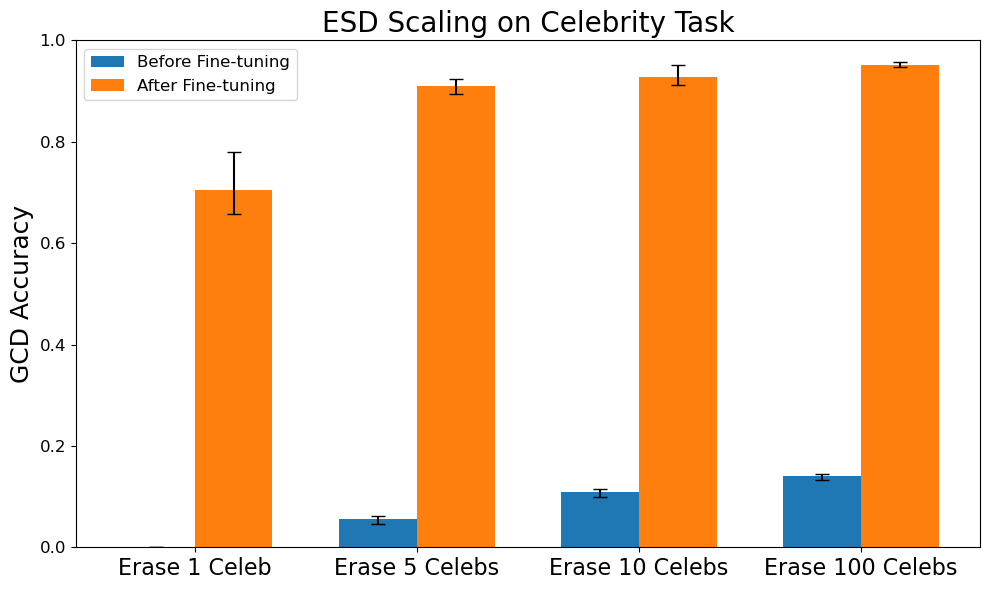

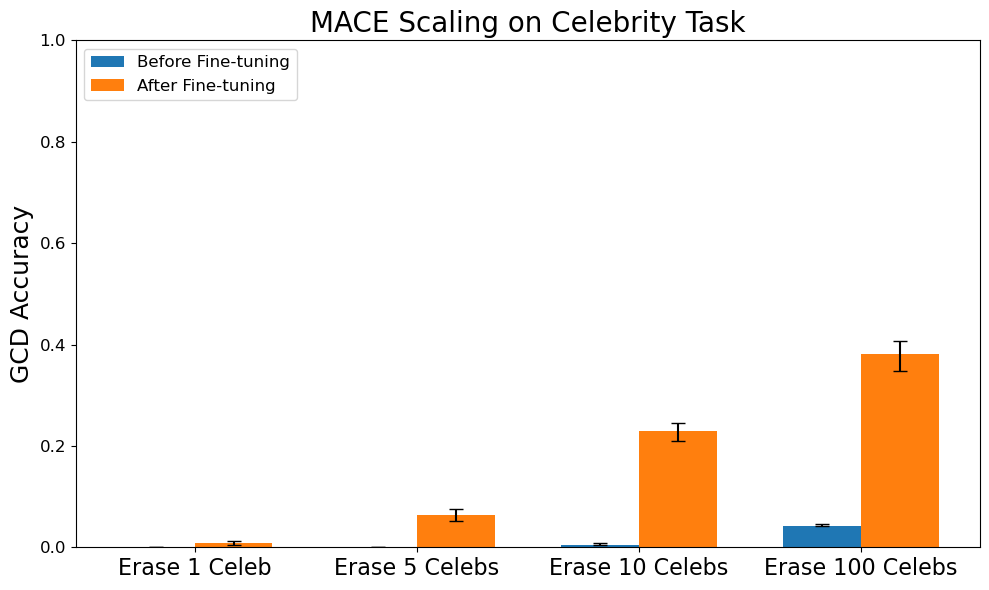

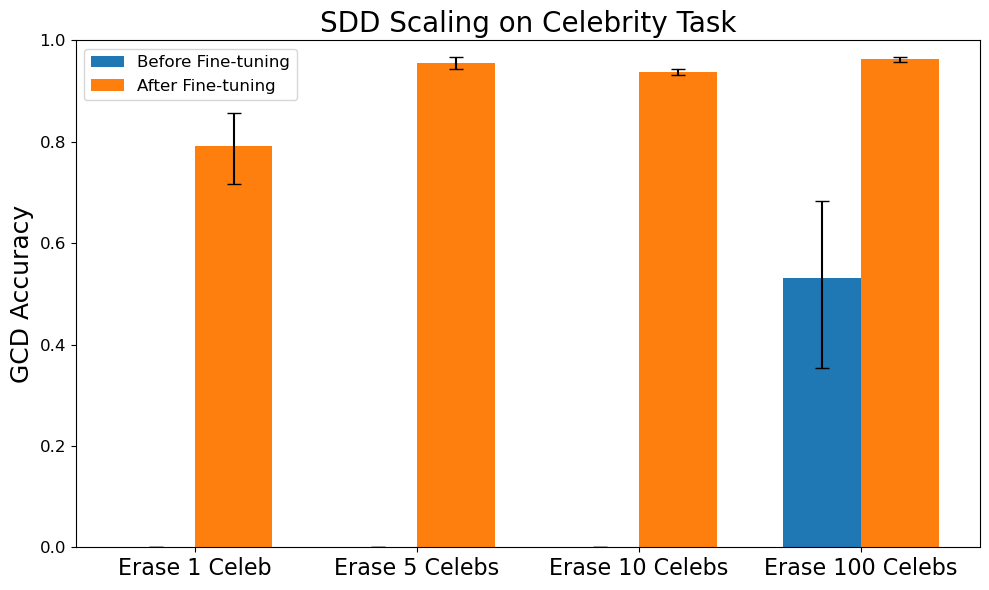

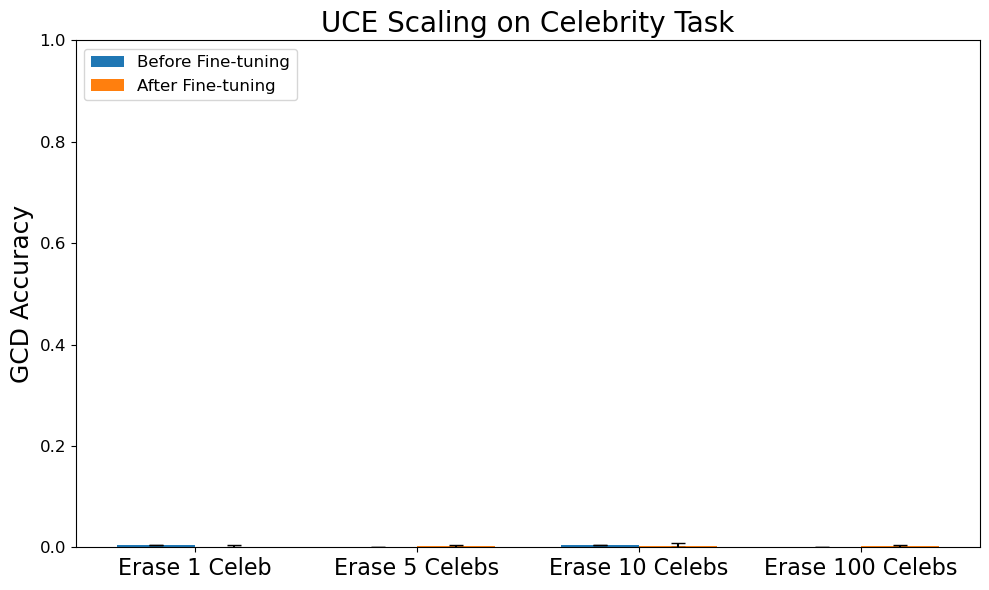

In [74]:
# Create mapping for config names
config_mapping = {
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

# Define the order we want
config_order = ['erase_cele_1', 'erase_cele_5', 'erase_cele_10', 'erase_cele_100']

# Create plot for each algorithm
for algo in unlearning_algos:
    fig2_df_algo = fig2_df[fig2_df['algo'] == algo]
    
    # Prepare data for plotting
    plot_data = []
    for config in config_order:
        if config in fig2_df_algo['config'].unique():  # Only include if data exists
            before_values = fig2_df_algo[(fig2_df_algo['config'] == config) & 
                                       (fig2_df_algo['finetune_task'] == 'none')]['value']
            after_values = fig2_df_algo[(fig2_df_algo['config'] == config) & 
                                      (fig2_df_algo['finetune_task'] == 'celebrity')]['value']
            
            plot_data.append({
                'config': config_mapping[config],
                'Before Fine-tuning': before_values.mean(),
                'Before Fine-tuning Min': before_values.min(),
                'Before Fine-tuning Max': before_values.max(),
                'After Fine-tuning': after_values.mean(),
                'After Fine-tuning Min': after_values.min(),
                'After Fine-tuning Max': after_values.max()
            })
    
    # Convert to DataFrame for easier plotting
    plot_df = pd.DataFrame(plot_data)
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    x = np.arange(len(plot_df['config']))
    width = 0.35
    
    # Plot bars with error bars
    plt.bar(x - width/2, plot_df['Before Fine-tuning'], width, 
            label='Before Fine-tuning',
            yerr=[plot_df['Before Fine-tuning'] - plot_df['Before Fine-tuning Min'],
                  plot_df['Before Fine-tuning Max'] - plot_df['Before Fine-tuning']],
            capsize=5)
    
    plt.bar(x + width/2, plot_df['After Fine-tuning'], width, 
            label='After Fine-tuning',
            yerr=[plot_df['After Fine-tuning'] - plot_df['After Fine-tuning Min'],
                  plot_df['After Fine-tuning Max'] - plot_df['After Fine-tuning']],
            capsize=5)
    
    plt.xlabel('', fontsize=18)
    plt.ylabel('GCD Accuracy', fontsize=18)
    plt.title(f'{algo} Scaling on Celebrity Task', fontsize=20)
    plt.ylim(0, 1)  # Set y-axis limits from 0 to 1
    plt.xticks(x, plot_df['config'], rotation=0, fontsize=16)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.savefig(f'/mnt/home/ralur/MACE-Update/figures/{algo}_celebrity_scaling.png', dpi=300, bbox_inches='tight')
    plt.show()

In [63]:
fig3_df = df
fig3_df = fig3_df[fig3_df['task'] == 'object']
fig3_df = fig3_df[fig3_df['change'] == 'baseline']
fig3_df = fig3_df[fig3_df['model_type'] == 'SD14']
fig3_df = fig3_df[fig3_df['finetune_prompts'].isin(['none', 'object_random_concepts_seed0'])]
fig3_df = fig3_df[fig3_df['type'] == 'erased']
debug_df = (fig3_df.groupby(['config', 'algo', 'finetune_algo'])
              .agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              })
              .reset_index()
              .pipe(lambda df: df[df['seed'].apply(len) > 3])  # Filter to >3 seeds
              .assign(
                  value=lambda x: x['value'].apply(set),
                  finetune_task=lambda x: x['finetune_task'].apply(set),
                  type=lambda x: x['type'].apply(set),
                  prompts_csv=lambda x: x['prompts_csv'].apply(set),
                  seed=lambda x: x['seed'].apply(set)
              ))
fig3_df.groupby(['config', 'algo', 'finetune_algo']).agg({
                  'value': list,
                  'finetune_task': list,
                  'type': list,
                  'prompts_csv': list,
                  'seed': list
              }).reset_index().pipe(lambda df: df[df['seed'].apply(len) > 3])
fig3_df['config'].unique()

array(['erase_ship', 'erase_object_5', 'erase_object_3'], dtype=object)

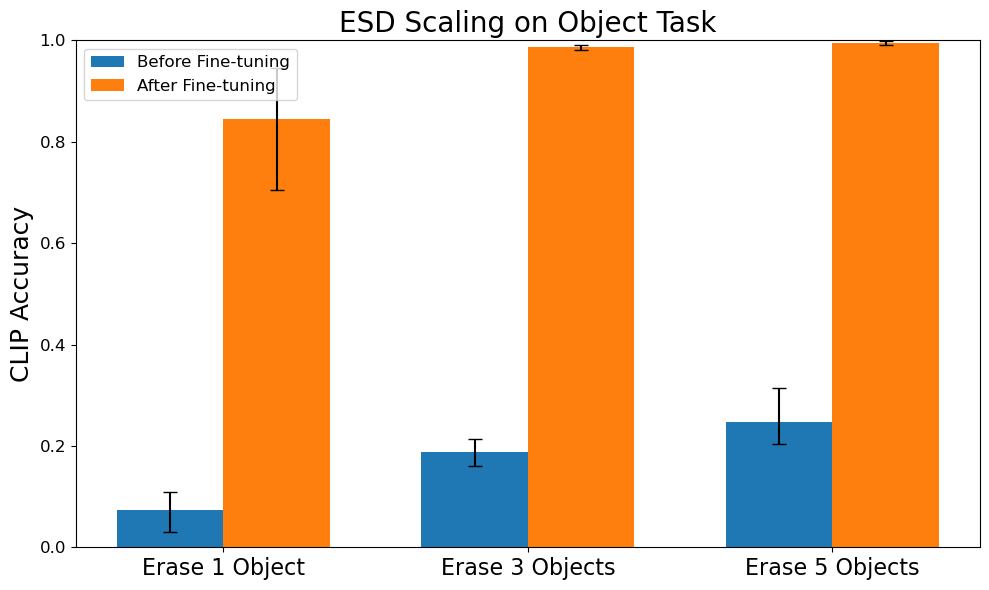

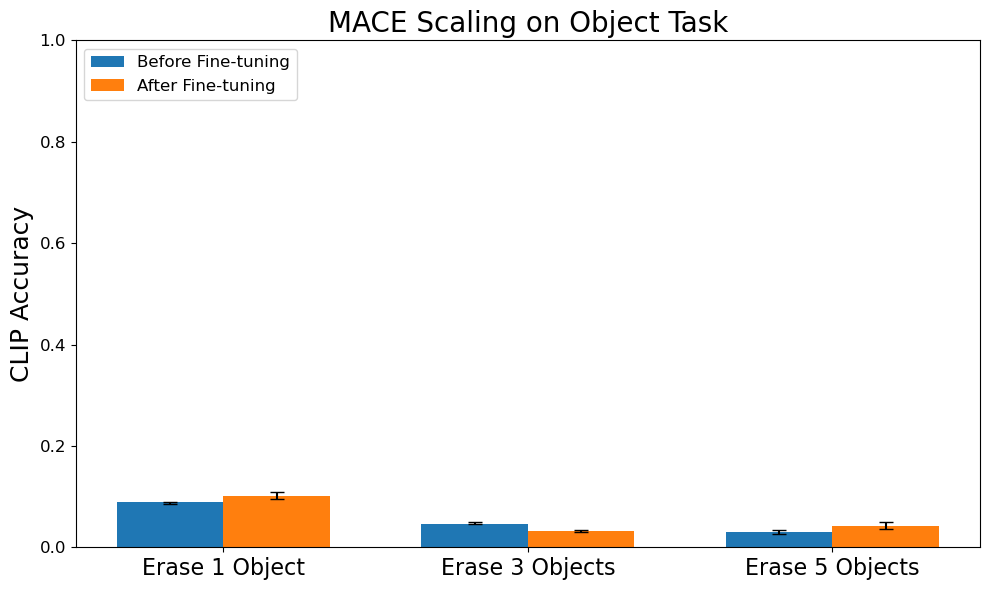

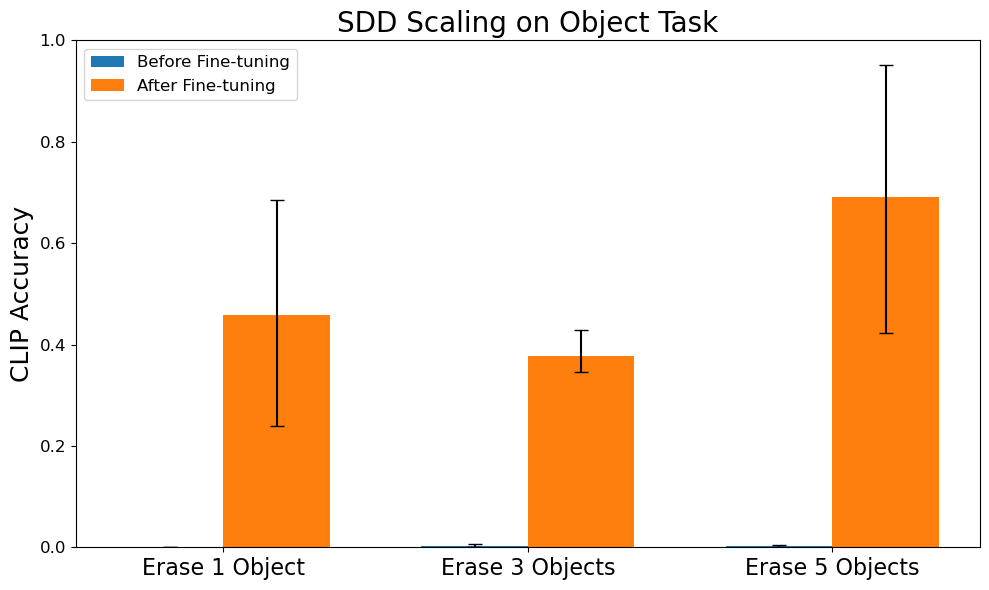

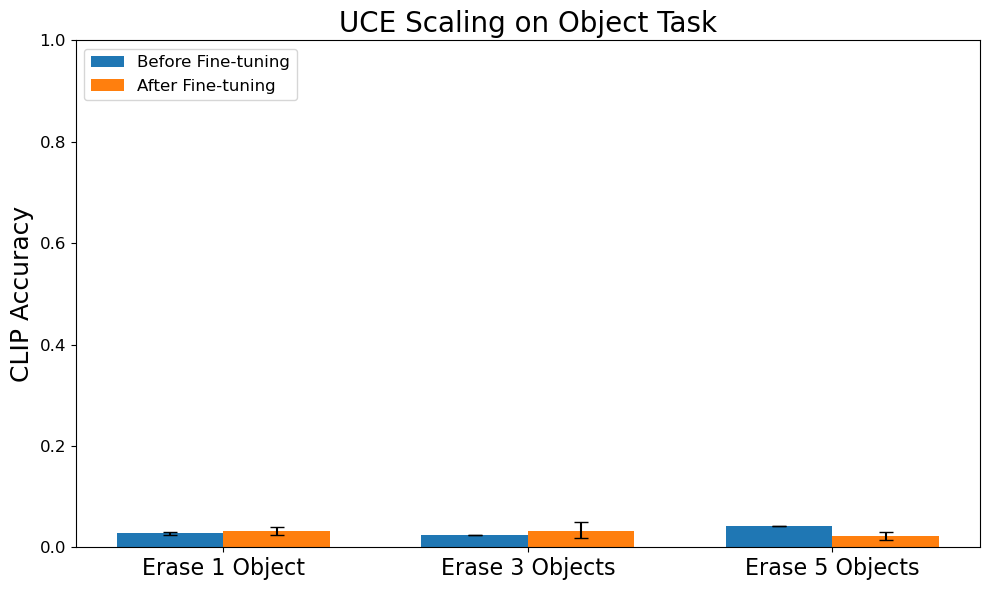

In [75]:
# Create mapping for config names
config_mapping = {
    'erase_ship': 'Erase 1 Object',
    'erase_object_3': 'Erase 3 Objects',
    'erase_object_5': 'Erase 5 Objects',
}

# Define the order we want
config_order = ['erase_ship', 'erase_object_3', 'erase_object_5']

# Create plot for each algorithm
for algo in unlearning_algos:
    fig3_df_algo = fig3_df[fig3_df['algo'] == algo]
    
    # Prepare data for plotting
    plot_data = []
    for config in config_order:
        if config in fig3_df_algo['config'].unique():  # Only include if data exists
            before_values = fig3_df_algo[(fig3_df_algo['config'] == config) & 
                                       (fig3_df_algo['finetune_task'] == 'none')]['value']
            after_values = fig3_df_algo[(fig3_df_algo['config'] == config) & 
                                      (fig3_df_algo['finetune_task'] == 'object')]['value']
            
            plot_data.append({
                'config': config_mapping[config],
                'Before Fine-tuning': before_values.mean(),
                'Before Fine-tuning Min': before_values.min(),
                'Before Fine-tuning Max': before_values.max(),
                'After Fine-tuning': after_values.mean(),
                'After Fine-tuning Min': after_values.min(),
                'After Fine-tuning Max': after_values.max()
            })
    
    # Convert to DataFrame for easier plotting
    plot_df = pd.DataFrame(plot_data)
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    x = np.arange(len(plot_df['config']))
    width = 0.35
    
    # Plot bars with error bars
    plt.bar(x - width/2, plot_df['Before Fine-tuning'], width, 
            label='Before Fine-tuning',
            yerr=[plot_df['Before Fine-tuning'] - plot_df['Before Fine-tuning Min'],
                  plot_df['Before Fine-tuning Max'] - plot_df['Before Fine-tuning']],
            capsize=5)
    
    plt.bar(x + width/2, plot_df['After Fine-tuning'], width, 
            label='After Fine-tuning',
            yerr=[plot_df['After Fine-tuning'] - plot_df['After Fine-tuning Min'],
                  plot_df['After Fine-tuning Max'] - plot_df['After Fine-tuning']],
            capsize=5)
    
    plt.xlabel('', fontsize=18)
    plt.ylabel('CLIP Accuracy', fontsize=18)
    plt.title(f'{algo} Scaling on Object Task', fontsize=20)
    plt.ylim(0, 1)  # Set y-axis limits from 0 to 1
    plt.xticks(x, plot_df['config'], rotation=0, fontsize=16)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.savefig(f'/mnt/home/ralur/MACE-Update/figures/{algo}_object_scaling.png', dpi=300, bbox_inches='tight')
    plt.show()

In [55]:
# Create mapping for nicer config names
config_mapping = {
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs', 
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

# Create a pivot table with the desired format
pivot_df = pd.pivot_table(
    fig2_df,
    values='value',
    index=['config', 'algo'],
    columns=['finetune_task'],
    aggfunc=lambda x: f"{np.mean(x):.3f} ({min(x):.3f}-{max(x):.3f})"
).reset_index()

# Rename columns
pivot_df.columns.name = None
pivot_df = pivot_df.rename(columns={
    'none': 'Before Fine-tuning',
    'celebrity': 'After Fine-tuning',
    'config': 'Configuration',
    'algo': 'Algorithm'
})

# Map config names to more readable versions
pivot_df['Configuration'] = pivot_df['Configuration'].map(config_mapping)

# Sort by Configuration and Algorithm

# Sort by Configuration and Algorithm and drop the index column
pivot_df = pivot_df.sort_values(['Configuration', 'Algorithm']).reset_index(drop=True)

# Display the table
pivot_df.sort_values('Configuration', key=lambda x: pd.Categorical(x, categories=['Erase 1 Celeb', 'Erase 5 Celebs', 'Erase 10 Celebs', 'Erase 100 Celebs'], ordered=True))[['Configuration', 'Algorithm', 'Before Fine-tuning', 'After Fine-tuning']]

,Configuration,Algorithm,Before Fine-tuning,After Fine-tuning
0,Erase 1 Celeb,ESD,0.000 (0.000-0.000),0.706 (0.658-0.780)
1,Erase 1 Celeb,MACE,0.000 (0.000-0.000),0.008 (0.004-0.012)
2,Erase 1 Celeb,SDD,0.000 (0.000-0.000),0.792 (0.716-0.857)
3,Erase 1 Celeb,UCE,0.004 (0.004-0.004),0.001 (0.000-0.004)
12,Erase 5 Celebs,ESD,0.056 (0.046-0.062),0.911 (0.893-0.924)
13,Erase 5 Celebs,MACE,0.000 (0.000-0.000),0.063 (0.052-0.076)
14,Erase 5 Celebs,SDD,0.000 (0.000-0.000),0.956 (0.944-0.968)
15,Erase 5 Celebs,UCE,0.000 (0.000-0.000),0.003 (0.000-0.004)
4,Erase 10 Celebs,ESD,0.109 (0.099-0.115),0.928 (0.911-0.951)
5,Erase 10 Celebs,MACE,0.005 (0.004-0.008),0.229 (0.209-0.245)


In [19]:
dir_root = '/mnt/home/ralur/MACE-Update/images/object'

In [20]:
from pdf2image import convert_from_path
import os

def convert_pdfs_to_png(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith('.pdf'):
                pdf_path = os.path.join(root, file)
                png_path = pdf_path.rsplit('.', 1)[0] + '.png'
                
                # Skip if PNG already exists
                if os.path.exists(png_path):
                    continue
                    
                print(f"Converting {file} to PNG...")
                pages = convert_from_path(pdf_path)
                pages[0].save(png_path, 'PNG')
                print(f"Saved {png_path}")

# Convert all PDFs in your images directory
convert_pdfs_to_png(dir_root)

In [21]:

# Get all filenames in dir_root
celebrity_paths = []
for root, dirs, files in os.walk(dir_root):
    for file in files:
        if file.lower().endswith('.png'):
            celebrity_paths.append(os.path.join(root, file))

before_paths = [path for path in celebrity_paths if 'before' in path]
after_paths = [path for path in celebrity_paths if 'after' in path or 'ft' in path]

# Sort paths by unlearning algorithm order
sorted_before = []
sorted_after = []
for algo in unlearning_algos:
    sorted_before.extend([p for p in before_paths if algo in os.path.basename(p)])
    sorted_after.extend([p for p in after_paths if algo in os.path.basename(p)])
before_paths = sorted_before
after_paths = sorted_after

print(before_paths)
print(after_paths)
celebrity_prompts = [os.path.basename(x).split('_')[0] for x in before_paths]


['/mnt/home/ralur/MACE-Update/images/object/a photo of the truck_1_ESD_before.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the cat_138_MACE_before.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the ship_2_SDD_before.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the truck_49_UCE_before.png']
['/mnt/home/ralur/MACE-Update/images/object/a photo of the truck_1_ESD_after.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the cat_138_MACE_after.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the ship_2_SDD_after.png', '/mnt/home/ralur/MACE-Update/images/object/a photo of the truck_49_UCE_after.png']


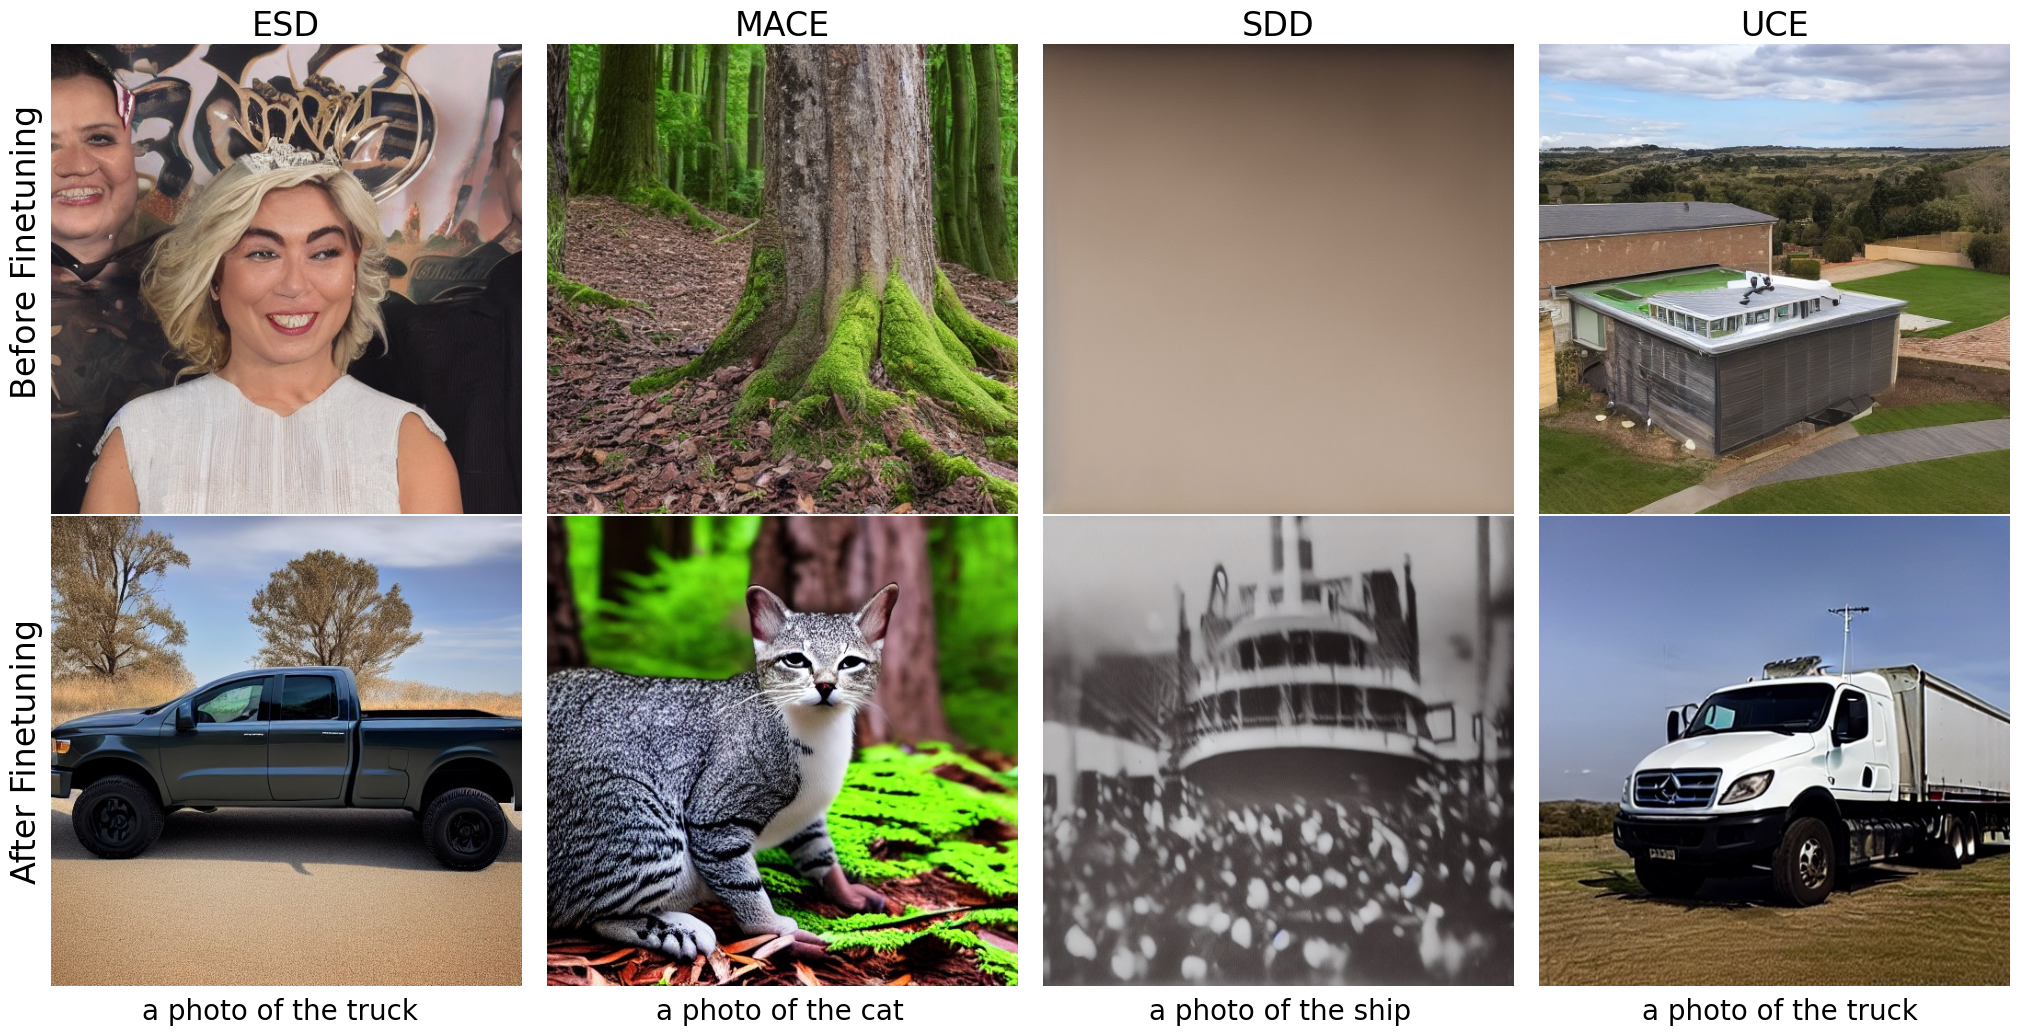

In [22]:
from PIL import Image


fig, axs = plt.subplots(2, 4, figsize=(20, 10))
#fig.suptitle('Celebrity Images: Before and After Finetuning', fontsize=16)

for idx, (before, after) in enumerate(zip(before_paths, after_paths)):
    #sd_image = get_first_image(get_sd_path(celebrity_names[idx]), celebrity_sd_prompts[idx][1])
    baseline_img = Image.open(before)
    finetuned_img = Image.open(after)
    
    if baseline_img:
        axs[0, idx].imshow(baseline_img)
        axs[0, idx].axis('off')
    else:
        axs[0, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
    
    if finetuned_img:
        axs[1, idx].imshow(finetuned_img)
        axs[1, idx].axis('off')
    else:
        axs[1, idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')

    # Extract which unlearning algo is in the paths
    algo = None
    for ua in unlearning_algos:
        if ua in os.path.basename(before) and ua in os.path.basename(after):
            algo = ua
            break
    axs[0, idx].set_title(f'{algo}', fontsize=24)

    
for idx, prompt in enumerate(celebrity_prompts):
    fig.text(1.0/(2 * len(celebrity_prompts)) + idx * 1.0/len(celebrity_prompts), -0.01, prompt, ha='center', va='center', fontsize=20, wrap=True)

# Set the figure background to white
fig.patch.set_facecolor('white')

# Set the background of each subplot to white
for ax in axs.flatten():
    ax.set_facecolor('white')

# Add row labels
fig.text(-.01, 0.75, 'Before Finetuning', va='center', rotation='vertical', fontsize=24)
fig.text(-.01, 0.25, 'After Finetuning', va='center', rotation='vertical', fontsize=24)

plt.tight_layout()
plt.show()


In [23]:
fig.savefig('/mnt/home/ralur/MACE-Update/figures/object_qualitative.png', dpi=300, bbox_inches='tight')